Import necessary libraries

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import hog, local_binary_pattern, graycomatrix, graycoprops
from skimage import color
import urllib.request, ssl

Step 1: Load Image

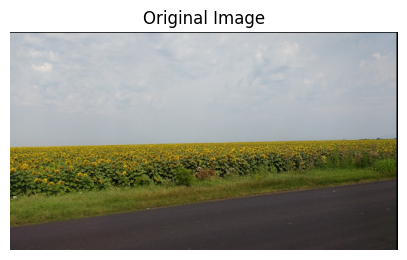

In [3]:
url = "https://drive.google.com/uc?export=download&id=1qeZiVX0DGS0klpEUDrtgi2M8PLg-3p7b"
ctx = ssl._create_unverified_context()
req = urllib.request.urlopen(url, context=ctx)
arr = np.asarray(bytearray(req.read()), dtype=np.uint8)
img = cv2.imdecode(arr, cv2.IMREAD_COLOR)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(5,5))
plt.imshow(img_rgb); plt.title("Original Image"); plt.axis('off')
plt.show()

Step 2: Histogram of Oriented Gradients (HOG)

    Captures edge orientations, invariant to illumination and pose

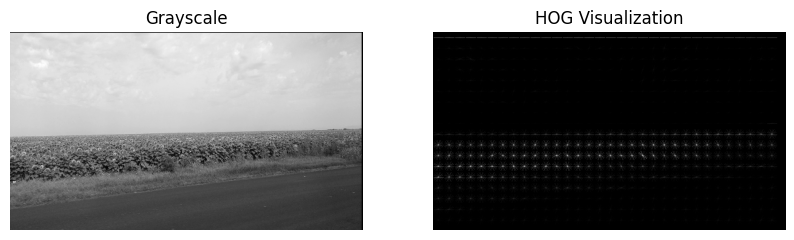

In [4]:
fd, hog_image = hog(gray, orientations=9, pixels_per_cell=(16,16),
                    cells_per_block=(2,2), visualize=True, channel_axis=None)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.imshow(gray, cmap='gray'); plt.title("Grayscale")
plt.axis('off')
plt.subplot(1,2,2); plt.imshow(hog_image, cmap='gray'); plt.title("HOG Visualization")
plt.axis('off')
plt.show()

Step 3: Edge Density

    Measures the ratio of edge pixels to the total pixels

▶ Edge Density = 0.062


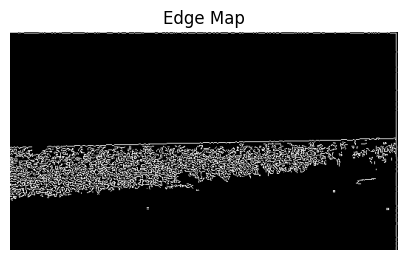

In [5]:
edges = cv2.Canny(gray, 100, 200)
edge_density = np.sum(edges > 0) / edges.size
print(f"\u25B6 Edge Density = {edge_density:.3f}")

plt.figure(figsize=(5,5))
plt.imshow(edges, cmap='gray'); plt.title("Edge Map"); plt.axis('off')
plt.show()

Step 4: Local Binary Pattern (LBP)

    Captures micro-patterns: for each pixel, threshold its neighbors

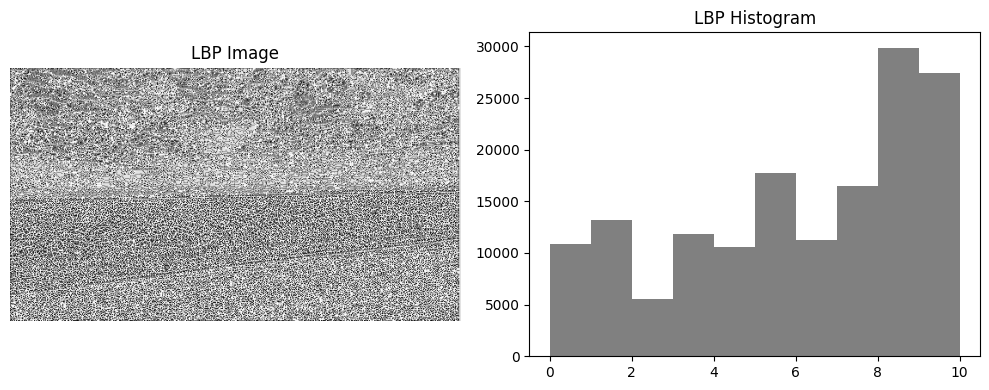

In [6]:
P, R = 8, 1
lbp = local_binary_pattern(gray, P, R, method='uniform')
bins = int(lbp.max() + 1)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.imshow(lbp, cmap='gray'); plt.title("LBP Image"); plt.axis('off')
plt.subplot(1,2,2); plt.hist(lbp.ravel(), bins=bins, range=(0, bins), color='gray')
plt.title("LBP Histogram")
plt.tight_layout()
plt.show()

Step 5: Gray Level Co-occurrence Matrix (GLCM)

    Measures pairwise intensity occurrence in a spatial offset

In [7]:
from skimage.util import img_as_ubyte

img_glcm = img_as_ubyte(gray)
glcm = graycomatrix(img_glcm, distances=[1], angles=[0, np.pi/4, np.pi/2], levels=256,
                    symmetric=True, normed=True)
props = ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation']
feat = {p: graycoprops(glcm, p).mean() for p in props}
print("\u25B6 GLCM Features:", feat)

▶ GLCM Features: {'contrast': np.float64(288.21698808712455), 'dissimilarity': np.float64(6.514883762696084), 'homogeneity': np.float64(0.4065523317765654), 'energy': np.float64(0.045722877806638584), 'correlation': np.float64(0.9631969046786727)}


Step 6: Laws' Texture Energy


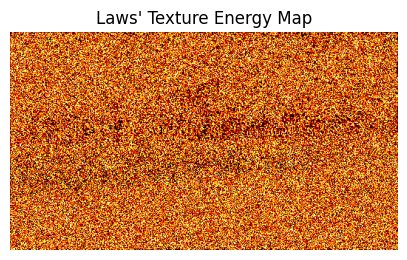

In [8]:
L5, E5, S5 = np.array([1,4,6,4,1]), np.array([-1,-2,0,2,1]), np.array([-1,0,2,0,-1])
kernels = [np.outer(a,b) for a in [L5,E5,S5] for b in [L5,E5,S5]]
energy_maps = [cv2.filter2D(gray, -1, k)**2 for k in kernels]
energy = sum(energy_maps) / len(energy_maps)

plt.figure(figsize=(5,5))
plt.imshow(energy, cmap='hot'); plt.title("Laws' Texture Energy Map"); plt.axis('off')
plt.show()

Summary Table

In [9]:
print("\n\u2605 Summary of Extracted Descriptors:")
print(f"- HOG feature length: {len(fd)}")
print(f"- Edge Density: {edge_density:.4f}")
print(f"- LBP Histogram bins: {bins}")
for k, v in feat.items():
    print(f"- GLCM {k}: {v:.4f}")


★ Summary of Extracted Descriptors:
- HOG feature length: 18972
- Edge Density: 0.0622
- LBP Histogram bins: 10
- GLCM contrast: 288.2170
- GLCM dissimilarity: 6.5149
- GLCM homogeneity: 0.4066
- GLCM energy: 0.0457
- GLCM correlation: 0.9632
